In [92]:
%matplotlib inline

import os
import sys
import numpy as np
import xarray as xr
import datacube
import skimage.exposure
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import colors as mcolours
from IPython.display import Image
from IPython.core.display import Video

from PIL import ImageSequence
from PIL import Image as pimg

import sys

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import xr_animation, rgb
from dea_tools.landcover import plot_land_cover, lc_animation, lc_colourmap

# Connect to dev sandbox database

In [93]:
dc = datacube.Datacube(app="lc3_vs_lc2")

# Display variable names of LC collections

In [94]:
"""
Parameter cell - add things here that are needed to run the rest of the notebook. This way the rest of the notebook can be left alone and shouldn't need to be edited.

Try to parameterise the name of the gifs too so they are fulling either from geojson filenames or similar
"""

# define collection and query parameters
lc_2_name = "ga_ls_landcover_class_cyear_2"
lc_3_name = "ga_ls_landcover_class_cyear_3"


x = (142.41, 142.57)
y = (-32.225, -32.325)

#define directories and filenames. These will be used in fstrings alter for generating consistent names for gifs.
output_dir = 'animation_col_comparison_outputs'
output_gif1 = 'test_animation_1'
output_gif2 = 'test_animation_2'


# Define input parameters for lc_animation to keep consistent across gifs.
interval=700
text_size = {'fontsize': 15}
dpi=150
label_ax=True
show_colorbar=True

# Query params
bands = ['level3', 'level4']
time = ('2015', '2020') # time series
year = '2020' #single epoch

In [95]:
# display collections' variable names (i.e., measurements)
measurements = dc.list_measurements()

for product in [lc_2_name, lc_3_name]:
    print(f'{product}\n')
    display(measurements.loc[product])
    print('\n\n')

ga_ls_landcover_class_cyear_2



,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,0,NaN,NaN
lifeform_veg_cat_l4a,lifeform_veg_cat_l4a,uint8,1,0,[lifeform],NaN
canopyco_veg_cat_l4d,canopyco_veg_cat_l4d,uint8,1,0,[vegetation_cover],NaN
watersea_veg_cat_l4a_au,watersea_veg_cat_l4a_au,uint8,1,0,[water_seasonality],NaN
waterstt_wat_cat_l4a,waterstt_wat_cat_l4a,uint8,1,0,[water_state],NaN
inttidal_wat_cat_l4a,inttidal_wat_cat_l4a,uint8,1,0,[intertidal],NaN
waterper_wat_cat_l4d_au,waterper_wat_cat_l4d_au,uint8,1,0,[water_persistence],NaN
baregrad_phy_cat_l4d_au,baregrad_phy_cat_l4d_au,uint8,1,0,[bare_gradation],NaN
level4,level4,uint8,1,0,[full_classification],NaN





ga_ls_landcover_class_cyear_3



,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,255,NaN,NaN
level4,level4,uint8,1,255,[full_classification],NaN


# Parameter cell

# Define colour palette

### Level 3 visualisation 

The Level 3 classification contains six base classes: 

* <strong>111: Cultivated terrestrial vegetation</strong>  
Cultivated vegetation is vegetation that has been changed by human influence, such as planted crops or improved pasture. This is different from areas left to minor grazing or fallow.
* <strong>112: Natural terrestrial vegetation</strong>  
Natural vegetation is vegetation that has not been changed by human influence. This includes native forests as well as pastures or paddocks left unchanged for the year. It does not identify whether the vegetation is native or otherwise.
* <strong>124: Natural aquatic vegetation</strong>  
Aquatic vegetation is vegetation that gets regularly inundated with water. Mangroves are the main type of aquatic vegetation featured in DEA Land Cover.
* <strong>215: Artificial surface</strong>  
Artificial surfaces are human-made, unvegetated areas. This includes the roofs of houses, concrete areas, road surfaces and other similar surfaces that we associate with civilisation.
* <strong>216: Natural bare surface</strong>  
Natural bare surface is mostly soil. It is very likely that there is still vegetation in the area, but it is dominated by soil.
* <strong>220: Water</strong>  
Water captures terrestrial and coastal open water such as dams, lakes, large rivers and the coastal and near-shore zone. 

To plot the `level3` data, we will use the `plot_layer()` function. 
The `plot_layer()` function allows you to define your own colour map as shown in the cell below. 
The keys respond to the Level 3 classifications, and the values are colour specifications (red, green, blue, alpha) and labels to be used in the legend.

In [96]:
# Define colour schemes for Levels 3 and 4
LEVEL3_COLOUR_SCHEME = {
    0: (255, 255, 255, 255, "No Data"),
    111: (172, 188, 45, 255, "Cultivated terrestrial vegetation"),
    112: (14, 121, 18, 255, "Natural terrestrial vegetation"),
    124: (30, 191, 121, 255, "Natural aquatic vegetation"),
    215: (218, 92, 105, 255, "Artificial surface"),
    216: (243, 171, 105, 255, "Natural bare surface"),
    220: (77, 159, 220, 255, "Water"),
}

LEVEL4_COLOUR_SCHEME = {
    0: (255, 255, 255, 255, "No Data"),
   1: (151, 187, 26, 255, 'Cultivated Terrestrial\n Vegetated:'),
   2: (151, 187, 26, 255, 'Cultivated Terrestrial\n Vegetated: Woody'),
   3: (209, 224, 51, 255, 'Cultivated Terrestrial\n Vegetated: Herbaceous'),
   4: (197, 168, 71, 255, 'Cultivated Terrestrial\n Vegetated: Closed\n (> 65 %)'),
   5: (205, 181, 75, 255, 'Cultivated Terrestrial\n Vegetated: Open\n (40 to 65 %)'),
   6: (213, 193, 79, 255, 'Cultivated Terrestrial\n Vegetated: Open\n (15 to 40 %)'),
   7: (228, 210, 108, 255, 'Cultivated Terrestrial\n Vegetated: Sparse\n (4 to 15 %)'),
   8: (242, 227, 138, 255, 'Cultivated Terrestrial\n Vegetated: Scattered\n (1 to 4 %)'),
   # 9: (197, 168, 71, 255, 'Cultivated Terrestrial\n Vegetated: Woody Closed\n (> 65 %)'),
   # 10: (205, 181, 75, 255, 'Cultivated Terrestrial\n Vegetated: Woody Open\n (40 to 65 %)'),
   # 11: (213, 193, 79, 255, 'Cultivated Terrestrial\n Vegetated: Woody Open\n (15 to 40 %)'),
   # 12: (228, 210, 108, 255, 'Cultivated Terrestrial\n Vegetated: Woody Sparse\n (4 to 15 %)'),
   # 13: (242, 227, 138, 255, 'Cultivated Terrestrial\n Vegetated: Woody Scattered\n (1 to 4 %)'),
   14: (228, 224, 52, 255, 'Cultivated Terrestrial\n Vegetated: Herbaceous Closed\n (> 65 %)'),
   15: (235, 232, 84, 255, 'Cultivated Terrestrial\n Vegetated: Herbaceous Open\n (40 to 65 %)'),
   16: (242, 240, 127, 255, 'Cultivated Terrestrial\n Vegetated: Herbaceous Open\n (15 to 40 %)'),
   17: (249, 247, 174, 255, 'Cultivated Terrestrial\n Vegetated: Herbaceous Sparse\n (4 to 15 %)'),
   18: (255, 254, 222, 255, 'Cultivated Terrestrial\n Vegetated: Herbaceous Scattered\n (1 to 4 %)'),
   19: (14, 121, 18, 255, 'Natural Terrestrial Vegetated:'),
   20: (26, 177, 87, 255, 'Natural Terrestrial Vegetated: Woody'),
   21: (94, 179, 31, 255, 'Natural Terrestrial Vegetated: Herbaceous'),
   22: (14, 121, 18, 255, 'Natural Terrestrial Vegetated: Closed (> 65 %)'),
   23: (45, 141, 47, 255, 'Natural Terrestrial Vegetated: Open (40 to 65 %)'),
   24: (80, 160, 82, 255, 'Natural Terrestrial Vegetated: Open (15 to 40 %)'),
   25: (117, 180, 118, 255, 'Natural Terrestrial Vegetated: Sparse (4 to 15 %)'),
   26: (154, 199, 156, 255, 'Natural Terrestrial Vegetated: Scattered (1 to 4 %)'),
   27: (14, 121, 18, 255, 'Natural Terrestrial Vegetated: Woody Closed (> 65 %)'),
   28: (45, 141, 47, 255, 'Natural Terrestrial Vegetated: Woody Open (40 to 65 %)'),
   29: (80, 160, 82, 255, 'Natural Terrestrial Vegetated: Woody Open (15 to 40 %)'),
   30: (117, 180, 118, 255, 'Natural Terrestrial Vegetated: Woody Sparse (4 to 15 %)'),
   31: (154, 199, 156, 255, 'Natural Terrestrial Vegetated: Woody Scattered (1 to 4 %)'),
   32: (119, 167, 30, 255, 'Natural Terrestrial Vegetated: Herbaceous Closed (> 65 %)'),
   33: (136, 182, 51, 255, 'Natural Terrestrial Vegetated: Herbaceous Open (40 to 65 %)'),
   34: (153, 196, 80, 255, 'Natural Terrestrial Vegetated: Herbaceous Open (15 to 40 %)'),
   35: (170, 212, 113, 255, 'Natural Terrestrial Vegetated: Herbaceous Sparse (4 to 15 %)'),
   36: (186, 226, 146, 255, 'Natural Terrestrial Vegetated: Herbaceous Scattered (1 to 4 %)'),
   # 37: (86, 236, 231, 255, 'Cultivated Aquatic Vegetated:'),
   # 38: (61, 170, 140, 255, 'Cultivated Aquatic Vegetated: Woody'),
   # 39: (82, 231, 172, 255, 'Cultivated Aquatic Vegetated: Herbaceous'),
   # 40: (43, 210, 203, 255, 'Cultivated Aquatic Vegetated: Closed (> 65 %)'),
   # 41: (73, 222, 216, 255, 'Cultivated Aquatic Vegetated: Open (40 to 65 %)'),
   # 42: (110, 233, 228, 255, 'Cultivated Aquatic Vegetated: Open (15 to 40 %)'),
   # 43: (149, 244, 240, 255, 'Cultivated Aquatic Vegetated: Sparse (4 to 15 %)'),
   # 44: (187, 255, 252, 255, 'Cultivated Aquatic Vegetated: Scattered (1 to 4 %)'),
   # 45: (43, 210, 203, 255, 'Cultivated Aquatic Vegetated: Woody Closed (> 65 %)'),
   # 46: (73, 222, 216, 255, 'Cultivated Aquatic Vegetated: Woody Open (40 to 65 %)'),
   # 47: (110, 233, 228, 255, 'Cultivated Aquatic Vegetated: Woody Open (15 to 40 %)'),
   # 48: (149, 244, 240, 255, 'Cultivated Aquatic Vegetated: Woody Sparse (4 to 15 %)'),
   # 49: (187, 255, 252, 255, 'Cultivated Aquatic Vegetated: Woody Scattered (1 to 4 %)'),
   # 50: (82, 231, 196, 255, 'Cultivated Aquatic Vegetated: Herbaceous Closed (> 65 %)'),
   # 51: (113, 237, 208, 255, 'Cultivated Aquatic Vegetated: Herbaceous Open (40 to 65 %)'),
   # 52: (144, 243, 220, 255, 'Cultivated Aquatic Vegetated: Herbaceous Open (15 to 40 %)'),
   # 53: (175, 249, 232, 255, 'Cultivated Aquatic Vegetated: Herbaceous Sparse (4 to 15 %)'),
   # 54: (207, 255, 244, 255, 'Cultivated Aquatic Vegetated: Herbaceous Scattered (1 to 4 %)'),
   55: (30, 191, 121, 255, 'Natural Aquatic Vegetated:'),
   56: (18, 142, 148, 255, 'Natural Aquatic Vegetated: Woody'),
   57: (112, 234, 134, 255, 'Natural Aquatic Vegetated: Herbaceous'),
   58: (25, 173, 109, 255, 'Natural Aquatic Vegetated: Closed (> 65 %)'),
   59: (53, 184, 132, 255, 'Natural Aquatic Vegetated: Open (40 to 65 %)'),
   60: (93, 195, 155, 255, 'Natural Aquatic Vegetated: Open (15 to 40 %)'),
   61: (135, 206, 178, 255, 'Natural Aquatic Vegetated: Sparse (4 to 15 %)'),
   62: (176, 218, 201, 255, 'Natural Aquatic Vegetated: Scattered (1 to 4 %)'),
   63: (25, 173, 109, 255, 'Natural Aquatic Vegetated: Woody Closed (> 65 %)'),
   64: (25, 173, 109, 255, 'Natural Aquatic Vegetated: Woody Closed (> 65 %) Water > 3 months (semi-) permenant'),
   65: (25, 173, 109, 255, 'Natural Aquatic Vegetated: Woody Closed (> 65 %) Water < 3 months (temporary or seasonal)'),
   66: (53, 184, 132, 255, 'Natural Aquatic Vegetated: Woody Open (40 to 65 %)'),
   67: (53, 184, 132, 255, 'Natural Aquatic Vegetated: Woody Open (40 to 65 %) Water > 3 months (semi-) permenant'),
   68: (53, 184, 132, 255, 'Natural Aquatic Vegetated: Woody Open (40 to 65 %) Water < 3 months (temporary or seasonal)'),
   69: (93, 195, 155, 255, 'Natural Aquatic Vegetated: Woody Open (15 to 40 %)'),
   70: (93, 195, 155, 255, 'Natural Aquatic Vegetated: Woody Open (15 to 40 %) Water > 3 months (semi-) permenant'),
   71: (93, 195, 155, 255, 'Natural Aquatic Vegetated: Woody Open (15 to 40 %) Water < 3 months (temporary or seasonal)'),
   72: (135, 206, 178, 255, 'Natural Aquatic Vegetated: Woody Sparse (4 to 15 %)'),
   73: (135, 206, 178, 255, 'Natural Aquatic Vegetated: Woody Sparse (4 to 15 %) Water > 3 months (semi-) permenant'),
   74: (135, 206, 178, 255, 'Natural Aquatic Vegetated: Woody Sparse (4 to 15 %) Water < 3 months (temporary or seasonal)'),
   75: (176, 218, 201, 255, 'Natural Aquatic Vegetated: Woody Scattered (1 to 4 %)'),
   76: (176, 218, 201, 255, 'Natural Aquatic Vegetated: Woody Scattered (1 to 4 %) Water > 3 months (semi-) permenant'),
   77: (176, 218, 201, 255, 'Natural Aquatic Vegetated: Woody Scattered (1 to 4 %) Water < 3 months (temporary or seasonal)'),
   78: (39, 204, 139, 255, 'Natural Aquatic Vegetated: Herbaceous Closed (> 65 %)'),
   79: (39, 204, 139, 255, 'Natural Aquatic Vegetated: Herbaceous Closed (> 65 %) Water > 3 months (semi-) permenant'),
   80: (39, 204, 139, 255, 'Natural Aquatic Vegetated: Herbaceous Closed (> 65 %) Water < 3 months (temporary or seasonal)'),
   81: (66, 216, 159, 255, 'Natural Aquatic Vegetated: Herbaceous Open (40 to 65 %)'),
   82: (66, 216, 159, 255, 'Natural Aquatic Vegetated: Herbaceous Open (40 to 65 %) Water > 3 months (semi-) permenant'),
   83: (66, 216, 159, 255, 'Natural Aquatic Vegetated: Herbaceous Open (40 to 65 %) Water < 3 months (temporary or seasonal)'),
   84: (99, 227, 180, 255, 'Natural Aquatic Vegetated: Herbaceous Open (15 to 40 %)'),
   85: (99, 227, 180, 255, 'Natural Aquatic Vegetated: Herbaceous Open (15 to 40 %) Water > 3 months (semi-) permenant'),
   86: (99, 227, 180, 255, 'Natural Aquatic Vegetated: Herbaceous Open (15 to 40 %) Water < 3 months (temporary or seasonal)'),
   87: (135, 239, 201, 255, 'Natural Aquatic Vegetated: Herbaceous Sparse (4 to 15 %)'),
   88: (135, 239, 201, 255, 'Natural Aquatic Vegetated: Herbaceous Sparse (4 to 15 %) Water > 3 months (semi-) permenant'),
   89: (135, 239, 201, 255, 'Natural Aquatic Vegetated: Herbaceous Sparse (4 to 15 %) Water < 3 months (temporary or seasonal)'),
   90: (171, 250, 221, 255, 'Natural Aquatic Vegetated: Herbaceous Scattered (1 to 4 %)'),
   91: (171, 250, 221, 255, 'Natural Aquatic Vegetated: Herbaceous Scattered (1 to 4 %) Water > 3 months (semi-) permenant'),
   92: (171, 250, 221, 255, 'Natural Aquatic Vegetated: Herbaceous Scattered (1 to 4 %) Water < 3 months (temporary or seasonal)'),
   93: (218, 92, 105, 255, 'Artificial Surface:'),
   94: (243, 171, 105, 255, 'Natural Surface:'),
   95: (255, 230, 140, 255, 'Natural Surface: Sparsely vegetated'),
   96: (250, 210, 110, 255, 'Natural Surface: Very sparsely vegetated'),
   97: (243, 171, 105, 255, 'Natural Surface: Bare areas, unvegetated'),
   98: (77, 159, 220, 255, 'Water:'),
   99: (77, 159, 220, 255, 'Water: (Water)'),
   100: (187, 220, 233, 255, 'Water: (Water) Tidal area'),
   101: (27, 85, 186, 255, 'Water: (Water) Perennial (> 9 months)'),
   102: (52, 121, 201, 255, 'Water: (Water) Non-perennial (7 to 9 months)'),
   103: (79, 157, 217, 255, 'Water: (Water) Non-perennial (4 to 6 months)'),
   104: (133, 202, 253, 255, 'Water: (Water) Non-perennial (1 to 3 months)'),
   # 105: (250, 250, 250, 255, 'Water: (Snow)')
   }


In [97]:
# lvl3_cmap, lvl3_norm = lc_colourmap('level3', colour_bar=False)
# lvl4_cmap, lvl4_norm = lc_colourmap('level4', colour_bar=False)

# lvl3_vmin = min(lvl3_norm.boundaries)
# lvl3_vmax = max(lvl3_norm.boundaries)

In [98]:
# generate cmaps
lvl3_colour_arr = []
# level 3 colours
for key, value in LEVEL3_COLOUR_SCHEME.items():
        lvl3_colour_arr.append(np.array(value[:-2]) / 255)

level_3_bounds = list(LEVEL3_COLOUR_SCHEME)
level_3_bounds.append(255)
level_3_cmap = mcolours.ListedColormap(lvl3_colour_arr)
level_3_norm = mcolours.BoundaryNorm(np.array(level_3_bounds) - 0.1, level_3_cmap.N)

lables = {'ticks' : [0,111,112,124,215,216,220],}

level_3_min = np.min(level_3_norm.boundaries)
level_3_max = np.max(level_3_norm.boundaries)



# # level 4 colours
# lvl4_colour_arr = []
# for key, value in LEVEL4_COLOUR_SCHEME.items():
#         lvl4_colour_arr.append(np.array(value[:-2]) / 255)


# level_4_cmap = mcolours.ListedColormap(lvl4_colour_arr)
# level_4_bounds = list(LEVEL4_COLOUR_SCHEME)


# level_4_bounds.append(255)

# level_4_norm = mcolours.BoundaryNorm(np.array(level_4_bounds) - 0.1, level_4_cmap.N)

# level_4_min = min(level_4_norm.boundaries)
# level_4_max = max(level_4_norm.boundaries)

In [99]:
level_3_norm.boundaries

array([-1.000e-01,  1.109e+02,  1.119e+02,  1.239e+02,  2.149e+02,
        2.159e+02,  2.199e+02,  2.549e+02])

# Load LC products

In [100]:
def query_comparison_single_year(lat, 
                                 lon, 
                                 buffer_size, 
                                 year):

    '''
    Generates dc.load() query for square buffers around coordinates of interest
    '''
    
    lat_range = (lat - buffer_size, lat + buffer_size)
    lon_range = (lon - buffer_size, lon + buffer_size)

    query = {
            "y": lat_range,
            "x": lon_range,
            "time": str(year),
            }

    return query


In [101]:
# define query

query = query_comparison_single_year(lat = -18.10, 
                                     lon = 122.32, 
                                     buffer_size = 0.2, # WGS84 (0.2 == ~ 20km)
                                     year = 2017,
                                    )

In [102]:
# LC collection 2
lc_2 = dc.load(
    product=lc_2_name,
    output_crs="EPSG:3577",
    measurements=[
        "level3",
        "level4",
    ],
    resolution=(-25, 25),
    **query
)


# LC collection 3
lc_3 = dc.load(
    product=lc_3_name,
    output_crs="EPSG:3577",
    measurements=[
        "level3",
        "level4",
    ],
    resolution=(-25, 25),
    **query
)

In [103]:
# concatenate the two collections into one dataset
# the dates reported in collection 3 are the 1st or the 2nd July, while collection 2 uses the 1st January
# thus, concatenating them across time dimension will place collection 2 in the first time step, and collection 3 in the second time step

combined_lc = xr.concat([lc_2, lc_3], dim='time')
combined_lc

<xarray.Dataset> Size: 14MB
Dimensions:      (time: 2, y: 1895, x: 1824)
Coordinates:
  * time         (time) datetime64[ns] 16B 2017-01-01 2017-07-02T11:59:59.999999
  * y            (y) float64 15kB -1.948e+06 -1.948e+06 ... -1.996e+06
  * x            (x) float64 15kB -1.046e+06 -1.046e+06 ... -1.001e+06
    spatial_ref  int32 4B 3577
Data variables:
    level3       (time, y, x) uint8 7MB 220 220 220 220 220 ... 112 112 112 112
    level4       (time, y, x) uint8 7MB 101 101 101 101 101 ... 34 34 34 34 34
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

Exporting animation to animated_timeseries.gif


  0%|          | 0/2 (0.0 seconds remaining at ? frames/s)

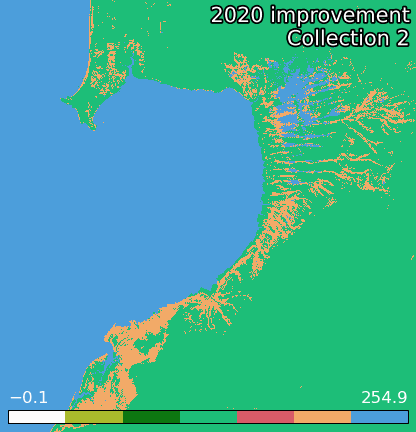

In [105]:
# Create animation

xr_animation(
    ds=combined_lc,
    bands=["level3"],
    output_path="animated_timeseries.gif",
    interval=500,
    width_pixels=300,
    show_date=False,
    show_text=[f'{year} improvement\n{i}' for i in ['Collection 2', 'Collection 3']],
    percentile_stretch=(0.01, 0.99),
    annotation_kwargs=text_size,
    imshow_kwargs={"cmap": level_3_cmap, "vmin": level_3_min, "vmax": level_3_max},
    show_colorbar=show_colorbar
    
)

# Plot animation
plt.close()
display(Image(filename="animated_timeseries.gif"))

In [ ]:
xr_animation(
    ds=combined_lc,
    bands=["level4"],
    output_path="animated_timeseries.gif",
    interval=500,
    width_pixels=300,
    show_date=False,
    show_text=[f'{year} improvement\n{i}' for i in ['Collection 2', 'Collection 3']],
    percentile_stretch=(0.01, 0.99),
    annotation_kwargs=text_size,
    imshow_kwargs={"cmap": level_4_cmap, "vmin": level_4_min, "vmax": level_4_max},
    show_colorbar=show_colorbar
    
)

# Plot animation
plt.close()
display(Image(filename="animated_timeseries.gif"))